In [4]:
import pandas as pd

In [5]:
from pathlib import Path
import polars as pl

PROJECT_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "pyproject.toml").is_file()
)
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
LAKE_DIR = DATA_DIR / "lake"
CAISO_DAM_LMP_DIR = LAKE_DIR / "power_gas" / "napg" / "caiso" / "dam_lmp"

def scan_parquet(dataset_dir: Path) -> pl.LazyFrame:
    """Lazily scan all Parquet partitions under a dataset directory."""
    files = sorted(dataset_dir.rglob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No Parquet files found under {dataset_dir}")
    return pl.scan_parquet([str(path) for path in files], hive_partitioning=True)

In [6]:
dam_lmp_df = scan_parquet(CAISO_DAM_LMP_DIR).collect().to_pandas()
dam_lmp_df

,interval_start_time_gmt,interval_end_time_gmt,opr_dt,opr_hr,opr_interval,node_id_xml,node_id,node,market_run_id,lmp_type,xml_data_item,pnode_resmrid,grp_type,pos,mw,group,year,month,day
0,2023-07-08 07:00:00+00:00,2023-07-08 08:00:00+00:00,2023-07-08,1,0,TH_SP15_GEN-APND,TH_SP15_GEN-APND,TH_SP15_GEN-APND,DAM,LMP,LMP_PRC,TH_SP15_GEN-APND,ALL_APNODES,0,33.33876,1,2023,7,8
1,2023-07-08 07:00:00+00:00,2023-07-08 08:00:00+00:00,2023-07-08,1,0,TH_SP15_GEN-APND,TH_SP15_GEN-APND,TH_SP15_GEN-APND,DAM,MCC,LMP_CONG_PRC,TH_SP15_GEN-APND,ALL_APNODES,0,0.00000,2,2023,7,8
2,2023-07-08 07:00:00+00:00,2023-07-08 08:00:00+00:00,2023-07-08,1,0,TH_SP15_GEN-APND,TH_SP15_GEN-APND,TH_SP15_GEN-APND,DAM,MCE,LMP_ENE_PRC,TH_SP15_GEN-APND,ALL_APNODES,0,34.23222,3,2023,7,8
3,2023-07-08 07:00:00+00:00,2023-07-08 08:00:00+00:00,2023-07-08,1,0,TH_SP15_GEN-APND,TH_SP15_GEN-APND,TH_SP15_GEN-APND,DAM,MCL,LMP_LOSS_PRC,TH_SP15_GEN-APND,ALL_APNODES,0,-0.89346,4,2023,7,8
4,2023-07-08 07:00:00+00:00,2023-07-08 08:00:00+00:00,2023-07-08,1,0,TH_SP15_GEN-APND,TH_SP15_GEN-APND,TH_SP15_GEN-APND,DAM,MGHG,LMP_GHG_PRC,TH_SP15_GEN-APND,ALL_APNODES,0,0.00000,5,2023,7,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285515,2026-10-09 06:00:00+00:00,2026-10-09 07:00:00+00:00,2026-10-08,24,0,TH_NP15_GEN-APND,TH_NP15_GEN-APND,TH_NP15_GEN-APND,DAM,LMP,LMP_PRC,TH_NP15_GEN-APND,ALL_APNODES,0,55.38380,66,2026,10,9
285516,2026-10-09 06:00:00+00:00,2026-10-09 07:00:00+00:00,2026-10-08,24,0,TH_NP15_GEN-APND,TH_NP15_GEN-APND,TH_NP15_GEN-APND,DAM,MCC,LMP_CONG_PRC,TH_NP15_GEN-APND,ALL_APNODES,0,-1.67858,67,2026,10,9
285517,2026-10-09 06:00:00+00:00,2026-10-09 07:00:00+00:00,2026-10-08,24,0,TH_NP15_GEN-APND,TH_NP15_GEN-APND,TH_NP15_GEN-APND,DAM,MCE,LMP_ENE_PRC,TH_NP15_GEN-APND,ALL_APNODES,0,50.54872,68,2026,10,9
285518,2026-10-09 06:00:00+00:00,2026-10-09 07:00:00+00:00,2026-10-08,24,0,TH_NP15_GEN-APND,TH_NP15_GEN-APND,TH_NP15_GEN-APND,DAM,MCL,LMP_LOSS_PRC,TH_NP15_GEN-APND,ALL_APNODES,0,-3.35945,69,2026,10,9


<Axes: >

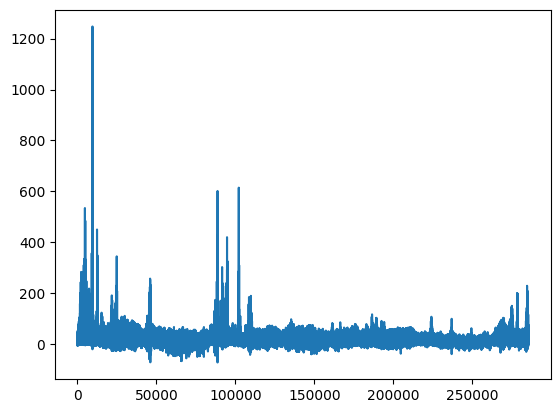

In [9]:
dam_lmp_df[dam_lmp_df['node'] == 'TH_SP15_GEN-APND']['mw'].plot()